## <span style="color:#50C878; font-weight:bold;">Load in Data</span>

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import RFE
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import joblib
from collections import defaultdict
import category_encoders as ce
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Load the dataset
data = pd.read_csv('Car_Kh24.csv')

df = pd.DataFrame(data)

# df.info()
# data.isnull().sum()
# df.nunique()

## <span style="color:#50C878; font-weight:bold;">Data Preprocessing</span>

### <span style="color:#50C878; font-weight:bold;">Remove NULL Row</span>


In [2]:
feature_has_missing_values = [
    feature for feature in df.columns if df[feature].isnull().any()
]
df = df.dropna(subset=feature_has_missing_values, how="any")
df.isnull().sum()

Ad ID           0
Category        0
Locations       0
Car Makes       0
Car Model       0
Year            0
Tax Type        0
Condition       0
Body Type       0
Fuel            0
Transmission    0
Color           0
Link            0
Title           0
Price           0
Year Used       0
dtype: int64

### <span style="color:#50C878; font-weight:bold;">Remove Duplicate Data</span>


In [3]:
# find duplicates
duplicates = df[df.duplicated()]

# count duplicates
print(f"Number of duplicate rows: {len(duplicates)}")

#drop duplicates
df = df.drop_duplicates()

Number of duplicate rows: 3


### <span style="color:#50C878; font-weight:bold;">Remove Unknown Data</span>


In [4]:
def check_column_value(df, value):
    """
    Checks if each column in a pandas DataFrame contains a specific value and prints the column names that contain the value.
    
    Parameters:
        df (pandas DataFrame): The DataFrame to check.
        value (any type): The value to look for in each column.
    """
    values = value if isinstance(value, list) else [value]
    matching_columns = df.apply(lambda col: col.isin(values).any())
    matching_columns = matching_columns[matching_columns]

    count = defaultdict(list)
    index = set()

    for val in values:
        for col in matching_columns.index:
            count[col].append(df[df[col] == val].shape[0])
            index.update(df[df[col] == val].index)

    print(f"\033[94mColumns that contain {values}:\n")
    print(pd.Series(count))

    return index

In [5]:
index = check_column_value(df, ['Other', 'Other - ផ្សេងៗ'])
df = df.drop(index, axis='rows')

Columns that contain ['Other', 'Other - ផ្សេងៗ']:

Car Model     [0, 53]
Body Type    [920, 0]
Color        [274, 0]
dtype: object


### <span style="color:#50C878; font-weight:bold;">Drop Unused Columns</span>

In [6]:
df.columns = df.columns.str.strip()

# columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Fuel', 'Transmission', 'Color', 'Link', 'Title', 'Year Used']
columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Link', 'Title']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df.columns

Index(['Car Makes', 'Car Model', 'Year', 'Tax Type', 'Condition', 'Body Type',
       'Fuel', 'Transmission', 'Color', 'Price', 'Year Used'],
      dtype='object')

### <span style="color:#50C878; font-weight:bold;">Convert Price from String to Float</span>

In [7]:
df['Price'] = df['Price'].apply(lambda x: x.split('$')[1].replace(',', '')).astype(float)
df['Price'].dtype

dtype('float64')

### <span style="color:#50C878; font-weight:bold;">Convert Year from Float to Integer</span>

In [8]:
# df["Year"] = df["Year"].astype(int)
# df.Year.dtype

### <span style="color:#50C878; font-weight:bold;">Feature Engineering</span>

In [9]:
# Add 'Car Age' feature
df['Car Age'] = 2025 - df['Year']

# Add 'Price per Year' feature
df['Price per Year'] = df['Price'] / (2025 - df['Year'])

### <span style="color:#50C878; font-weight:bold;">Binning</span>

In [10]:
# z = round(df.groupby(['Car Makes'])['Price'].agg(['mean']), 2)
# min, max = z.agg(['min','max']).values
# df = df.merge(z, how='left', on='Car Makes')

# bin_width = (min + max) / 3
# bins = [i for i in range(int(24600.9100), int(np.ceil(max)), int(np.ceil(bin_width)))]
# bins[-1] = int(np.ceil(max))
# bins.insert(0, 0)

# cars_bin = ['Budget', 'Medium', 'High-End']
# df['Price Range'] = pd.cut(df['mean'], bins=bins, right=False, labels=cars_bin)
# # df.head()

### <span style="color:#50C878; font-weight:bold;">Handle Skewed Data</span>

C:\Users\PCN\AppData\Local\Temp\ipykernel_11748\1392703603.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )


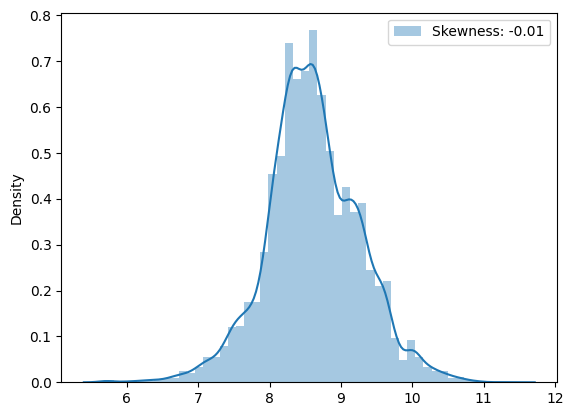

In [11]:
def boxcox(new_df, col):

    # Box-Cox transformation
    transformed_data, lambda_param = stats.boxcox(new_df[col])

    Boxcox = pd.Series(transformed_data)
    
    t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )
    t.legend()
    return Boxcox, lambda_param

price_boxcox, price_lambda = boxcox(df, 'Price')

C:\Users\PCN\AppData\Local\Temp\ipykernel_11748\1392703603.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )


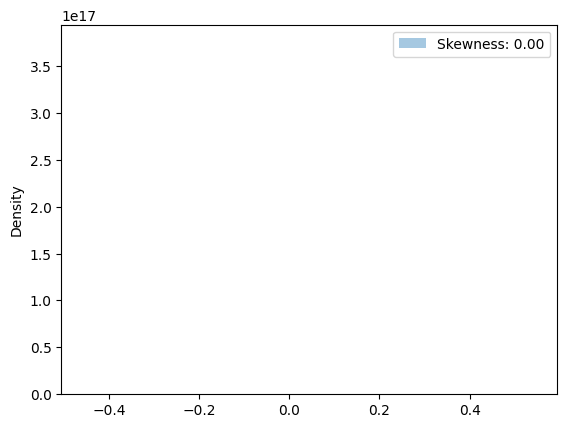

In [12]:
year_boxcox, year_lambda = boxcox(df, 'Year')

In [13]:
df_boxcox = df.copy()
df_boxcox['Price'] = list(price_boxcox)
df_boxcox.shape, df.shape

((11859, 13), (11859, 13))

### <span style="color:#50C878; font-weight:bold;">Detect Outlier</span>

In [14]:
# func to Inter-quartile Range Method
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [15]:
def visualize_outlier(df, col):
    out_iqr(df, col)
    plt.figure(figsize = (10,6))
    sns.distplot(df[col], kde=False)
    plt.axvspan(xmin = lower,xmax= df.Price.min(),alpha=0.2, color='red')
    plt.axvspan(xmin = upper,xmax= df.Price.max(),alpha=0.2, color='red')
    plt.show()

In [16]:
# visualize_outlier(df_boxcox, 'Price')

In [17]:
# visualize_outlier(df, 'Price')

### <span style="color:#50C878; font-weight:bold;">Remove Outlier</span>

In [18]:
def outlier_detection(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    upper_end = Q3 + 1.5 * IQR
    lower_end = Q1 - 1.5 * IQR
    outlier = df[(df > upper_end) | (df < lower_end)]
    return outlier

In [19]:
# # Define price threshold (optional, based on your data)
# price_lower_threshold = df['Price'].quantile(0.25)
# price_upper_threshold = df['Price'].quantile(0.75)

# # Filter out rows where price is out of the defined range
# df = df[(df['Price'] > price_lower_threshold) & (df['Price'] < price_upper_threshold)]

outlier_index = list(outlier_detection(df_boxcox['Price']).index)
df = df_boxcox.drop(outlier_index, axis= 'rows')

### <span style="color:#50C878; font-weight:bold;">Encoding</span>

In [20]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features

['Car Makes',
 'Car Model',
 'Tax Type',
 'Condition',
 'Body Type',
 'Fuel',
 'Transmission',
 'Color']

In [21]:
# # Label Encoding
# le = LabelEncoder()

# # Columns to encode
# categorical_cols = ['Car Model']

# # Apply label encoding to categorical columns
# for col in categorical_cols:
#     df[col] = le.fit_transform(df[col])

# # One-Hot Encoding
# df = pd.get_dummies(df, columns=['Car Makes', 'Tax Type', 'Condition', 'Body Type'])

df = pd.get_dummies(df, columns=categorical_features)

# # df.head()

# Target Encoding
# target_encoder = ce.TargetEncoder(cols= categorical_features)

## <span style="color:#50C878; font-weight:bold;">Model</span>

### <span style="color:#50C878; font-weight:bold;">Train the Elastic Net Regression Model</span>

In [22]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for future use
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

Scaler saved as 'scaler.pkl'


### <span style="color:#50C878; font-weight:bold;">Cross-Validation</span>

In [23]:
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.7, max_iter=1000000)
elastic_net_model.fit(X_train_scaled, y_train)

y_pred = elastic_net_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

joblib.dump(elastic_net_model, 'Model-7.pkl')
print("Model saved as 'Model-7.pkl'")

loaded_model = joblib.load('Model-7.pkl')

y_pred_loaded = loaded_model.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_loaded)
rmse_best = root_mean_squared_error(y_test, y_pred_loaded)
r2_best = r2_score(y_test, y_pred_loaded)

print(f"Model MSE: {mse_best}")
print(f"Model RMSE: {rmse_best}")
print(f"Model R-squared: {r2_best}")
print("Model-7.pkl")

Mean Squared Error: 0.12067108243682031
Root Mean Squared Error: 0.34737743512902547
Mean Absolute Error: 0.2614921061814885
R-squared: 0.6783749072070959
Model saved as 'Model-7.pkl'
Model MSE: 0.12067108243682031
Model RMSE: 0.34737743512902547
Model R-squared: 0.6783749072070959
Model-7.pkl


### <span style="color:#50C878; font-weight:bold;">Feature selection</span>

In [24]:
# Recursive Feature Elimination (RFE)

# # Initialize the model
# model = ElasticNet(alpha=0.001, l1_ratio=0.7)

# # Initialize RFE
# rfe = RFE(estimator=model, n_features_to_select=10)

# # Fit RFE to the scaled training data
# rfe.fit(X_train_scaled, y_train)

# # Get selected feature names
# selected_rfe_features = X_train.columns[rfe.support_]
# print("Selected Features:", selected_rfe_features)

In [25]:
# # Tree-Based Feature Importance
# from sklearn.ensemble import RandomForestRegressor

# # Train a Random Forest model
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# # Get feature importances
# feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
# feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# print(feature_importances)

In [26]:
# # Regularization (Lasso)
# from sklearn.linear_model import Lasso

# # Fit Lasso model
# lasso = Lasso(alpha=0.01)
# lasso.fit(X_train_scaled, y_train)

# # Get non-zero coefficients
# selected_lasso_features = X_train.columns[lasso.coef_ != 0]
# print("Selected Features via Lasso:", selected_lasso_features)

In [27]:
# # Principal Component Analysis (PCA)
# from sklearn.decomposition import PCA

# # Apply PCA
# pca = PCA(n_components=10)
# X_train_pca = pca.fit_transform(X_train_scaled)
# print("Explained Variance Ratio:", pca.explained_variance_ratio_)

### <span style="color:#50C878; font-weight:bold;">Model Tuning</span>

In [28]:
# param_grid = {
#     'alpha': [0.001, 0.01, 0.1, 1, 10],
#     'l1_ratio': [0.1, 0.3, 0.5, 0.7, 1]
# }

# grid_search = GridSearchCV(ElasticNet(max_iter=1000000), param_grid, cv=5, scoring='neg_mean_squared_error')
# grid_search.fit(X_train_scaled, y_train)

# print("Best Hyperparameters:", grid_search.best_params_)

# best_model = grid_search.best_estimator_
# y_pred_best = best_model.predict(X_test_scaled)

# mse_best = mean_squared_error(y_test, y_pred_best)
# rmse_best = root_mean_squared_error(y_test, y_pred_best)
# r2_best = r2_score(y_test, y_pred_best)

# print(f"Best Model MSE: {mse_best}")
# print(f"Best Model RMSE: {rmse_best}")
# print(f"Best Model R-squared: {r2_best}")

# # Load the model from the file
# best_model = joblib.load('best_elasticnet_model.pkl')

# # Now you can use the loaded model to make predictions
# y_pred_loaded = best_model.predict(X_test_scaled)

# mse_best = mean_squared_error(y_test, y_pred_loaded)
# rmse_best = root_mean_squared_error(y_test, y_pred_loaded)
# r2_best = r2_score(y_test, y_pred_loaded)

# print(f"Model MSE: {mse_best}")
# print(f"Model RMSE: {rmse_best}")
# print(f"Model R-squared: {r2_best}")

# print("best_elasticnet_model.pkl")


### <span style="color:#50C878; font-weight:bold;">Cross-Validation</span>

In [29]:
# # Create a pipeline with scaling and the ElasticNet model
# model_pipeline = make_pipeline(StandardScaler(), elastic_net)

# # Perform 5-fold cross-validation
# cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# # Convert negative MSE to positive for easier interpretation
# cv_scores = -cv_scores

# # Print the cross-validation results
# print(f"Cross-Validation MSE Scores: {cv_scores}")
# print(f"Mean Cross-Validation MSE: {cv_scores.mean()}")
# print(f"Cross-Validation MSE Standard Deviation: {cv_scores.std()}")

# # You can also calculate R-squared using a similar approach
# cv_r2_scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')
# print(f"Mean R-squared: {cv_r2_scores.mean()}")
# print(f"R-squared Standard Deviation: {cv_r2_scores.std()}")


### <span style="color:#50C878; font-weight:bold;">Test</span>

In [30]:
# import pandas as pd
# from sklearn.preprocessing import StandardScaler

# # New car data (replace with actual car details)
# new_car_data = {
#     'Car Makes': ['Toyota', 'Honda', 'Toyota'],   # Example car make
#     'Car Model': ['Corolla', 'Civic', 'Prius'],  # Example car model
#     'Tax Type': ['Plate Number', 'Plate Number', 'Tax Paper'],       # Example tax type
#     'Condition': ['New', 'New', 'New'],  # Example car condition
#     'Body Type': ['Sedan', 'Sedan', 'Hatchback'],  # Example car condition
#     'Fuel': ['Petrol', 'Diesel', 'Hybrid'],        # Example fuel type
#     'Transmission': ['Automatic', 'Manual', 'Automatic'],  # Example transmission type
#     'Color': ['Black', 'White', 'Gray'],  # Example car color
# }


# # Convert new car data into DataFrame
# new_car_df = pd.DataFrame(new_car_data)

# categorical_features = new_car_df.select_dtypes(include=['object']).columns.tolist()
# categorical_features

# new_car_df = pd.get_dummies(new_car_df, columns=categorical_features)

# # # Standardize the new car data (same scaling as done during training)
# # scaler = StandardScaler()
# # new_car_data_transformed = scaler.fit_transform(new_car_df)

# loaded_model = joblib.load('Model-7.pkl')

# # Assuming 'model' is your trained model, use it to predict the price of the new car
# predicted_price = loaded_model.predict(new_car_df)

# # Output the predicted price
# for i, price in enumerate(predicted_price):
#     print(f"Predicted Price for Car {i+1}: ${price[0]:,.2f}")